In [1]:
import os
import torch
import itertools
from tqdm import tqdm
import clip
import nltk
from tqdm import tqdm
import seaborn as sns
import numpy as np
import pandas as pd
import cv2 as cv
from PIL import Image
from collections import defaultdict
from itertools import combinations
import matplotlib
import matplotlib.pyplot as plt
import torch.nn.functional as F
from scipy.ndimage import label, center_of_mass
from open_clip import create_model_from_pretrained, create_model_and_transforms, get_tokenizer 
from transformers import AutoModel, AutoProcessor
from PIL import Image, ImageDraw, ImageFont
from transformers.image_utils import load_image

from utils import default_argument_parser, Compute_IoU, extract_noun_phrase, gen_dir_mask, extract_dir_phrase, extract_rela_word, relation_boxes, extract_nouns, mask_to_bbox_mask, mask_iou_diversity, extract_noun_phrase_aug, generate_candidates


In [4]:
folder_dir = '/home/nsml/notebooks'
file_name = 'giraffe.jpeg'
file_path = os.path.join(folder_dir, file_name)

vision_model_type = "google/siglip-base-patch16-384"
device = 'cuda:1'
pool_mode = 'full'
dim = 24

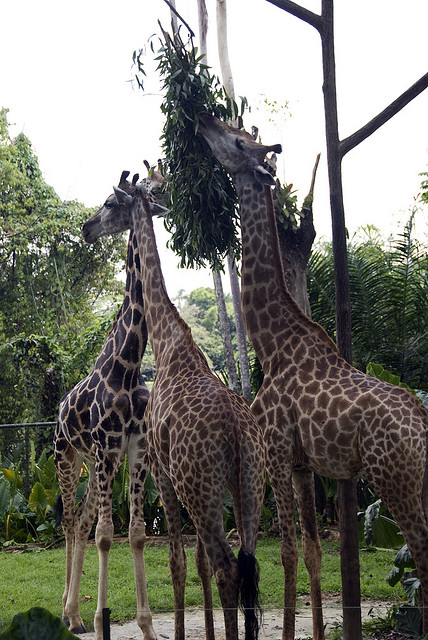

In [5]:
img = cv.imread(file_path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img = Image.fromarray(img)
img.show()  

In [6]:
orig_text_lst = ["the giraffe in the middle"]

In [7]:
idx = 0

In [8]:
CACHE_DIR = "/mnt/tmp/"

model = AutoModel.from_pretrained(vision_model_type).to(device)
tokenizer = AutoProcessor.from_pretrained(vision_model_type).tokenizer
processor = AutoProcessor.from_pretrained(vision_model_type)

vision_model = model.vision_model
vision_model

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


SiglipVisionTransformer(
  (embeddings): SiglipVisionEmbeddings(
    (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
    (position_embedding): Embedding(576, 768)
  )
  (encoder): SiglipEncoder(
    (layers): ModuleList(
      (0-11): 12 x SiglipEncoderLayer(
        (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attn): SiglipAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): SiglipMLP(
          (activation_fn): PytorchGELUTanh()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bi

In [9]:
target_layers = ['vision_model.encoder.layers[0].layer_norm1',
                 'vision_model.encoder.layers[1].layer_norm1',
                 'vision_model.encoder.layers[2].layer_norm1',
                 'vision_model.encoder.layers[3].layer_norm1',
                 'vision_model.encoder.layers[4].layer_norm1',
                 'vision_model.encoder.layers[5].layer_norm1',
                 'vision_model.encoder.layers[6].layer_norm1',
                 'vision_model.encoder.layers[7].layer_norm1',
                 'vision_model.encoder.layers[8].layer_norm1',
                 'vision_model.encoder.layers[9].layer_norm1',
                 'vision_model.encoder.layers[10].layer_norm1',
                 'vision_model.encoder.layers[11].layer_norm1']

In [10]:
def get_activation(outputs, mode):
    '''
    mode: how to pool activations: one of avg, max
    for fc or ViT neurons does no pooling
    '''
    if mode=='avg':
        def hook(model, input, output):
            # print(output.shape)
            if len(output.shape)==4: #CNN layers
                outputs.append(output.mean(dim=[2,3]).detach())
            elif len(output.shape)==3: #ViT
                if output.shape[1] == 1:
                    outputs.append(output[:, 0].clone())
                elif output.shape[1] == 0:
                    outputs.append(output[0, :].clone())
            elif len(output.shape)==2: #FC layers
                outputs.append(output.detach())
    elif mode=='max':
        def hook(model, input, output):
            if len(output.shape)==4: #CNN layers
                outputs.append(output.amax(dim=[2,3]).detach())
            elif len(output.shape)==3: #ViT
                outputs.append(output[:, 0].clone())
            elif len(output.shape)==2: #FC layers
                outputs.append(output.detach())
    elif mode=='full':
        def hook(model, input, output):
            outputs.append(output.detach())
    return hook

In [11]:
all_features = {target_layer:[] for target_layer in target_layers}
    
hooks = {}
for target_layer in tqdm(target_layers):
    command = "model.{}.register_forward_hook(get_activation(all_features[target_layer], pool_mode))".format(target_layer)
    hooks[target_layer] = eval(command)

100%|██████████| 12/12 [00:00<00:00, 14807.78it/s]


In [12]:
local_candidates = ['giraffe']
r = 0.6

In [13]:
inputs = processor(images=[load_image(img)], return_tensors="pt").to(device)
local_text = tokenizer(local_candidates, return_tensors="pt", padding="max_length", max_length=64).to(device)
global_text = tokenizer([orig_text_lst[idx]], return_tensors="pt", padding="max_length", max_length=64).to(device)

with torch.no_grad():
    image_features = model.get_image_features(**inputs)    
    local_text_features = model.get_text_features(**local_text)
    global_text_features = model.get_text_features(**global_text)
    hybrid_text_features = r * global_text_features + (1-r) * local_text_features 
    print(image_features.shape, hybrid_text_features.shape)

torch.Size([1, 768]) torch.Size([1, 768])


In [14]:
image_features /= image_features.norm(dim=-1, keepdim=True)
hybrid_text_features /= hybrid_text_features.norm(dim=-1, keepdim=True)
sim_matrix = (image_features @ hybrid_text_features.T)
sim_matrix

tensor([[0.0988]], device='cuda:1')

In [15]:
best_idx = sim_matrix[0].argmax(dim=-1).item()
local_candidates = [local_candidates[best_idx]]
local_candidates

['giraffe']

In [17]:
for i,layer_num in enumerate(range(12)): 
    inter_features = all_features[f'vision_model.encoder.layers[{layer_num}].layer_norm1'][0]
    inter_features = vision_model.post_layernorm(-inter_features)
    # inter_features = vision_model.head(inter_features)
    new_features_temp = inter_features.unsqueeze(0)

    new_features_temp = inter_features
    if i == 0:
        new_features = new_features_temp
    else:
        new_features = torch.cat((new_features, new_features_temp), 0)
    print(new_features.shape)
    print()

torch.Size([1, 576, 768])

torch.Size([2, 576, 768])

torch.Size([3, 576, 768])

torch.Size([4, 576, 768])

torch.Size([5, 576, 768])

torch.Size([6, 576, 768])

torch.Size([7, 576, 768])

torch.Size([8, 576, 768])

torch.Size([9, 576, 768])

torch.Size([10, 576, 768])

torch.Size([11, 576, 768])

torch.Size([12, 576, 768])



In [18]:
inputs = processor(images=[load_image(img)], return_tensors="pt").to(device)
local_text = tokenizer(local_candidates, return_tensors="pt", padding="max_length", max_length=64).to(device)
global_text = tokenizer([orig_text_lst[idx]], return_tensors="pt", padding="max_length", max_length=64).to(device)

with torch.no_grad():
    image_features = model.get_image_features(**inputs)    
    local_text_features = model.get_text_features(**local_text)
    global_text_features = model.get_text_features(**global_text)
    hybrid_text_features = r * global_text_features + (1-r) * local_text_features 
    print(image_features.shape, hybrid_text_features.shape)

torch.Size([1, 768]) torch.Size([1, 768])


In [19]:
new_features /= new_features.norm(dim=-1, keepdim=True)
hybrid_text_features /= hybrid_text_features.norm(dim=-1, keepdim=True)
sim_matrix = (new_features @ hybrid_text_features.T)
sim_matrix.shape

torch.Size([12, 576, 1])

In [20]:
sim_lst1 = []
sim_lst2 = []
for i in range(sim_matrix.shape[-1]):
    print('Word: ', local_candidates[i], '| Mean: ', sim_matrix[:, :, i].mean(1).mean(0).item(), '| Max: ', sim_matrix[:, :, i].max(1)[0].mean(0).item())
    print()
    sim_lst1.append(sim_matrix[:, :, i].mean(1).mean(0).item())
    sim_lst2.append(sim_matrix[:, :, i].max(1)[0].mean(0).item())

Word:  giraffe | Mean:  0.0038061279337853193 | Max:  0.09373500198125839



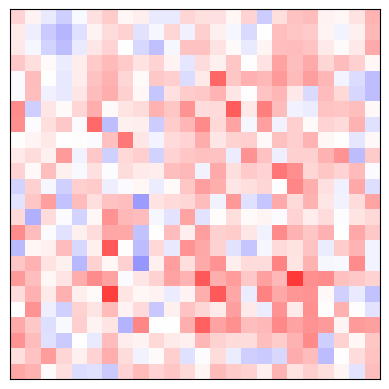

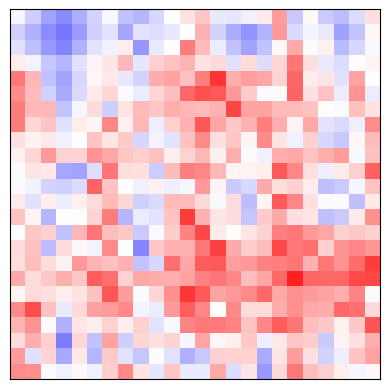

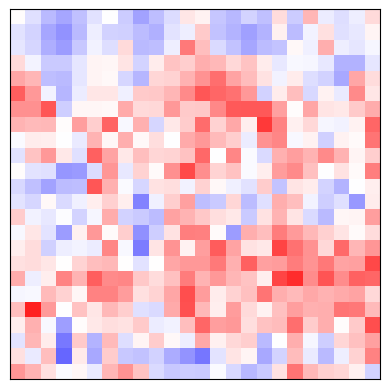

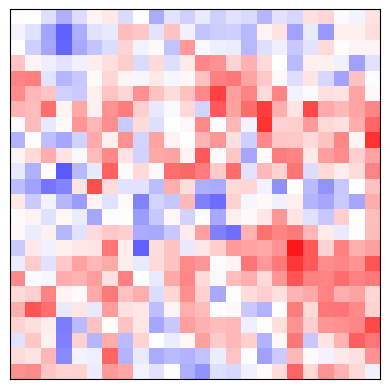

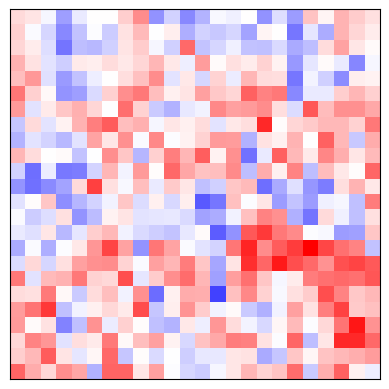

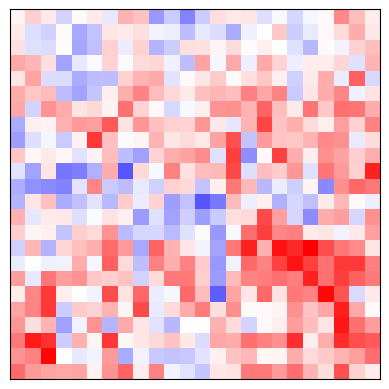

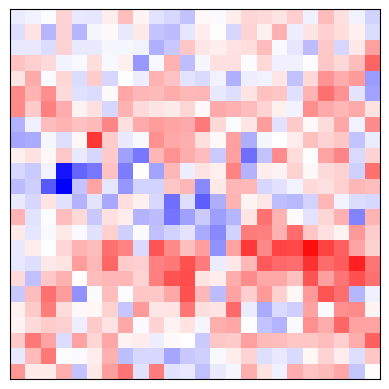

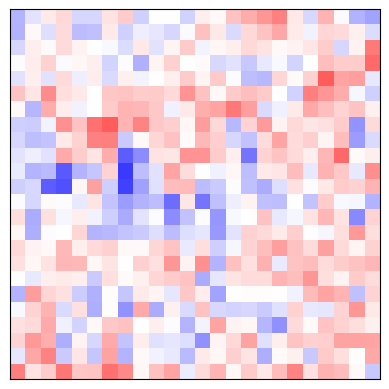

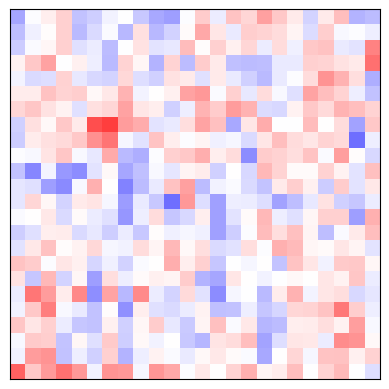

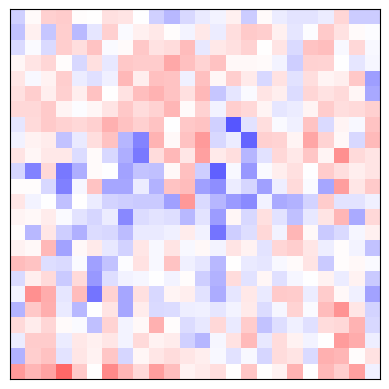

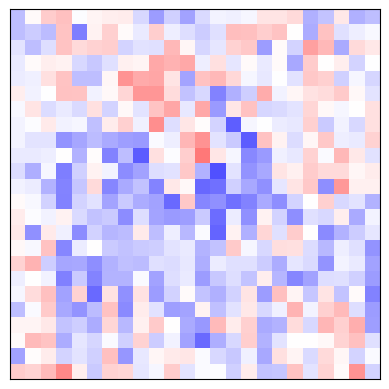

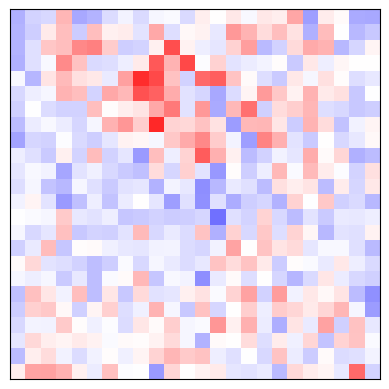

In [21]:
sns.set_style({'font.family':'serif', 'font.serif':['Times New Roman']})

cmap = plt.get_cmap('bwr')

min_v = sim_matrix[:, :, :].min().item()
max_v = sim_matrix[:, :, :].max().item()

mean_sim = sim_matrix[:, :, :].mean(0).unsqueeze(0)

clim_min = min_v
clim_max = max_v

for j in range(sim_matrix.shape[0]):
    plt.imshow(sim_matrix[j, :, idx].reshape(dim, dim).detach().cpu().numpy(), cmap=cmap)
    plt.xticks([])
    plt.yticks([])
    # plt.xticks(ticks=range(dim), labels=range(1, dim+1))
    # plt.yticks(ticks=range(dim), labels=range(1, dim+1))
    # plt.colorbar(shrink=0.8, aspect=20)
    plt.clim(clim_min, clim_max)
   
    # plt.title(f'Layer: {j}', fontsize=20)
    plt.show()

    low_percentile=10
    high_percentile=90

    # Flatten the array
    flattened = sim_matrix[j, :, idx].detach().cpu().numpy().flatten()
    
    # Compute percentiles
    low_threshold = np.percentile(flattened, low_percentile)
    high_threshold = np.percentile(flattened, high_percentile)
    
    # Extract low and high regions based on percentiles
    low_region = flattened[flattened <= low_threshold]
    high_region = flattened[flattened >= high_threshold]
    
    # Calculate mean values for low and high regions
    mean_low = np.mean(low_region).item()
    mean_high = np.mean(high_region).item()
    cluster_score = round(mean_high - mean_low, 2)
    
    # plt.figure(figsize=(5, 3))
    # plt.hist(sim_matrix[j, :, idx].detach().cpu().numpy(), color='#7adde3')
    # plt.axvline(mean_low, color='gray', linewidth=0.75)
    # plt.axvline(mean_high, color='gray', linewidth=0.75)
    # plt.xlim(min_v, max_v)
    # plt.tight_layout()
    # plt.title(f'{local_candidates[idx]} (Cluster score: {cluster_score})', fontsize=15) 
    # plt.show()


# plt.imshow(sim_matrix[11:, :, idx].mean(0).reshape(dim, dim).detach().cpu().numpy(), cmap=cmap)
# plt.xticks([])
# plt.yticks([])
# plt.xticks(ticks=range(dim), labels=range(1, dim+1))
# plt.yticks(ticks=range(dim), labels=range(1, dim+1))
# plt.colorbar(shrink=0.8, aspect=20)
# plt.clim(clim_min, clim_max)

# plt.title(f'{orig_text_lst[idx]} (Mean)', fontsize=15)
# plt.show()